# ChestNet: pretrained ViT on the original 7,685-image subset

This experiment recreates the original rarest-first, seeded subset and its patient-level 70/15/15 split. It trains the improved ViT-B/16 on the original eight labels and evaluates on the original test patients. The original validation patients are divided into model-selection and threshold-tuning groups; this difference and the changed training procedure mean the comparison is informative but not a single-variable architecture ablation.

Run on Kaggle with the NIH Chest X-rays dataset, Internet enabled, and GPU T4 x2. All code and outputs are saved in this notebook version; the inference weights and metric files are exported separately.


In [1]:
# Use the Kaggle-provided CUDA PyTorch; install only the model package if needed.
import importlib.util, subprocess, sys
if importlib.util.find_spec('timm') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'timm==1.0.27'])

## 1. Configuration and GPU

The default batch is eight images per GPU with two accumulation steps (effective batch 32 on two GPUs, 16 on one). CUDA mixed precision saves memory. DataParallel uses both attached GPUs; all saved weights belong to the underlying model and can later run on one GPU or CPU. Validation uses float32 scores and exact scikit-learn AUC. If CUDA is absent this cell stops before attempting an expensive CPU training run.

The preset was pretrained on ImageNet-21k and fine-tuned on ImageNet-1k; we replace its classifier with eight independent logits. Its normalization comes from its pretrained configuration. [Model card](https://huggingface.co/timm/vit_base_patch16_224.augreg_in21k_ft_in1k).

In [2]:
import os, json, math, random, time, hashlib, platform, shutil, warnings
from pathlib import Path
from contextlib import nullcontext
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from torchvision.transforms import InterpolationMode
import timm
import sklearn
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_recall_curve,
    roc_curve, f1_score, multilabel_confusion_matrix, accuracy_score)
from IPython.display import display, Markdown, FileLink

CFG = {
    'seed': 42,
    'data_root': None,  # If auto-discovery is ambiguous, set to the dataset directory.
    'output_dir': '/kaggle/working/chestnet_vit_balanced_7685',
    'cache_dir': '/kaggle/temp/chestnet_vit_balanced_7685_cache',
    'model_name': 'vit_base_patch16_224.augreg_in21k_ft_in1k',
    'image_size': 224,
    'batch_per_gpu': 8,
    'accumulation_steps': 2,
    'workers': 4,
    'use_two_gpus': True,
    'amp': True,
    'cache_images': True,
    'max_images_per_class': 1500,
    'split_candidates': 200,
    'min_positives_per_split': 30,
    'max_pos_weight': 20.0,
    'weight_decay': 0.05,
    'head_dropout': 0.2,
    'drop_path': 0.1,
    'patience': 3,
    'min_delta': 0.0005,
    'warmup_fraction': 0.1,
    'max_train_hours': 7.0,
    'bootstrap_repeats': 200,
    'resume_from': None,  # Our latest.pt from an attached previous notebook output.
    'stages': [
        {'name': 'head', 'epochs': 2, 'head_lr': 3e-4, 'backbone_lr': 0.0},
        {'name': 'last_blocks', 'epochs': 5, 'head_lr': 1e-4, 'backbone_lr': 1e-5},
        {'name': 'full', 'epochs': 8, 'head_lr': 5e-5, 'backbone_lr': 3e-6},
    ],
}
CLASSES = ['Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
           'Mass', 'Nodule', 'Pneumonia', 'No Finding']
SEED = CFG['seed']
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(4)
if not torch.cuda.is_available():
    raise RuntimeError('Enable a Kaggle GPU accelerator before running this notebook.')
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
# Fixed seeds improve repeatability; parallel CUDA operations are not guaranteed bit-identical.
DEVICE = torch.device('cuda:0')
GPU_COUNT = min(2, torch.cuda.device_count()) if CFG['use_two_gpus'] else 1
BATCH = CFG['batch_per_gpu'] * GPU_COUNT
OUT = Path(CFG['output_dir']); OUT.mkdir(parents=True, exist_ok=True)
environment = {
    'torch': str(torch.__version__), 'timm': timm.__version__, 'numpy': np.__version__,
    'pandas': pd.__version__, 'sklearn': sklearn.__version__, 'python': platform.python_version(),
    'gpus': [torch.cuda.get_device_name(i) for i in range(GPU_COUNT)],
    'effective_batch': BATCH * CFG['accumulation_steps'],
}
(OUT / 'environment.json').write_text(json.dumps(environment, indent=2))
(OUT / 'config.json').write_text(json.dumps(CFG, indent=2))
subprocess.run([sys.executable, '-m', 'pip', 'freeze'], stdout=(OUT / 'requirements-frozen.txt').open('w'), check=True)
print(environment)

{'torch': '2.11.0+cu128', 'timm': '1.0.29', 'numpy': '2.1.3', 'pandas': '2.3.3', 'sklearn': '1.6.1', 'python': '3.13.15', 'gpus': ['Tesla T4', 'Tesla T4'], 'effective_batch': 32}


## 2. Recreate and audit the original balanced subset

The original script samples up to 1,500 images per class, processing rarer classes first and allowing one image to count for multiple labels. It uses seed 42 and preserves the CSV row order during sampling. We verify all selected images and record the exact subset and split identities. The test patient split is checked against the original notebook's saved counts.


In [3]:
def load_metadata(root_override=None):
    search_root = Path(root_override) if root_override else Path('/kaggle/input')
    csvs = sorted(search_root.rglob('Data_Entry_2017.csv'))
    if len(csvs) != 1:
        raise RuntimeError(f'Expected one NIH metadata CSV, found {len(csvs)}. Set CFG[data_root].')
    csv_path = csvs[0]
    root = Path(root_override) if root_override else csv_path.parent
    df = pd.read_csv(csv_path, dtype={'Image Index': str, 'Patient ID': str})
    required = {'Image Index', 'Patient ID', 'Finding Labels'}
    if not required.issubset(df.columns) or df[list(required)].isna().any().any():
        raise ValueError('Missing required metadata values or columns.')
    df = df.rename(columns={'Image Index':'image', 'Patient ID':'patient_id', 'Finding Labels':'labels'})
    if df.image.duplicated().any():
        raise ValueError('Duplicate image names in metadata.')
    known = set(CLASSES) | {'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
                           'Hernia', 'Pleural_Thickening', 'Pneumothorax'}
    label_sets = df.labels.map(lambda s: set(s.split('|')))
    unknown = set().union(*label_sets) - known
    if unknown: raise ValueError(f'Unexpected labels: {unknown}')
    if any('No Finding' in s and len(s) > 1 for s in label_sets):
        raise ValueError('No Finding co-occurs with a disease; resolve the label conflict first.')
    for c in CLASSES: df[c] = label_sets.map(lambda s, c=c: int(c in s))
    index = {}
    for directory, _, files in os.walk(root, followlinks=True):
        for name in files:
            if name.lower().endswith('.png'):
                path = str(Path(directory) / name)
                if name in index and os.path.realpath(index[name]) != os.path.realpath(path):
                    raise ValueError(f'Ambiguous image filename: {name}')
                index[name] = path
    df['path'] = df.image.map(index)
    missing = df[df.path.isna()]
    if len(missing):
        missing[['image','patient_id']].to_csv(OUT / 'missing_images.csv', index=False)
        raise FileNotFoundError(f'{len(missing)} metadata images are absent. Attach all image archives.')
    df = df.reset_index(drop=True)
    df['cache_index'] = np.arange(len(df))
    audit = {
        'metadata_images': len(df), 'patients': int(df.patient_id.nunique()),
        'images_with_only_unselected_diseases': int((df[CLASSES].sum(axis=1) == 0).sum()),
        'image_bytes': int(sum(Path(p).stat().st_size for p in df.path)),
        'metadata_sha256': hashlib.sha256(csv_path.read_bytes()).hexdigest(),
        'image_downsampling': True,
    }
    audit['image_gib'] = audit['image_bytes'] / 1024**3
    if 'Patient Age' in df:
        age = pd.to_numeric(df['Patient Age'], errors='coerce')
        audit['invalid_ages'] = int(((age < 0) | (age > 100) | age.isna()).sum())
    return df, audit

df, audit = load_metadata(CFG['data_root'])
eligible = df[df[CLASSES].sum(axis=1) > 0].reset_index(drop=True)
# Match src/preprocessing/splits.py: metadata order, rarest class first, RNG seed 42.
rng = np.random.default_rng(SEED)
chosen = np.zeros(len(eligible), dtype=bool)
for c in sorted(CLASSES, key=lambda c: eligible[c].sum()):
    already = int(eligible.loc[chosen, c].sum())
    pool = np.flatnonzero((eligible[c].to_numpy() == 1) & ~chosen)
    take = max(0, min(CFG['max_images_per_class'] - already, len(pool)))
    if take:
        chosen[rng.choice(pool, size=take, replace=False)] = True
df = eligible.loc[chosen].reset_index(drop=True)
df['patient_id'] = pd.to_numeric(df.patient_id)
df['cache_index'] = np.arange(len(df))
assert len(df) == 7685, f'Original subset should have 7,685 images; got {len(df)}.'
audit.update({'subset_images': len(df), 'subset_patients': int(df.patient_id.nunique()),
              'eligible_selected_label_images': len(eligible),
              'max_images_per_class': CFG['max_images_per_class']})
df[['image','patient_id',*CLASSES]].to_csv(OUT / 'balanced_subset.csv', index=False)
DATA_HASH = hashlib.sha256(df[['image','patient_id',*CLASSES]].to_csv(index=False).encode()).hexdigest()
CACHE_PATH = Path(CFG['cache_dir']) / f'{DATA_HASH[:16]}_{CFG["image_size"]}.uint8'
CACHE_MARKER = CACHE_PATH.with_suffix('.complete.json')

def prepare_cache(frame):
    size = CFG['image_size']
    shape = (len(frame), size, size)
    if CFG['cache_images']:
        CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
        expected = int(np.prod(shape))
        if (CACHE_MARKER.exists() and CACHE_PATH.exists() and CACHE_PATH.stat().st_size == expected
                and json.loads(CACHE_MARKER.read_text()).get('data_hash') == DATA_HASH):
            return
        if shutil.disk_usage(CACHE_PATH.parent).free < expected + 1024**3:
            raise RuntimeError('Insufficient cache disk space. Set cache_images=False.')
        cache = np.memmap(CACHE_PATH, dtype='uint8', mode='w+', shape=shape)
    errors = []
    for i, path in enumerate(tqdm(frame.path, desc='Verify and resize images')):
        try:
            with Image.open(path) as im:
                im.load()  # Fully decode now, so broken images fail before training.
                if CFG['cache_images']:
                    cache[i] = np.asarray(im.convert('L').resize((size,size), Image.Resampling.BICUBIC))
        except Exception as exc:
            errors.append({'image':frame.iloc[i].image, 'error':str(exc)})
    if errors:
        pd.DataFrame(errors).to_csv(OUT / 'corrupt_images.csv', index=False)
        raise RuntimeError(f'{len(errors)} corrupted images; inspect corrupt_images.csv.')
    if CFG['cache_images']:
        cache.flush(); del cache
        CACHE_MARKER.write_text(json.dumps({'data_hash':DATA_HASH, 'shape':shape}))

prepare_cache(df)
audit['verified_subset_images'] = len(df)
(OUT / 'data_audit.json').write_text(json.dumps(audit, indent=2))
display(pd.Series(audit))
display(pd.DataFrame({'positives':df[CLASSES].sum(), 'prevalence':df[CLASSES].mean()}))

Verify and resize images:   0%|          | 0/7685 [00:00<?, ?it/s]

metadata_images                                                                    112120
patients                                                                            30805
images_with_only_unselected_diseases                                                 7840
image_bytes                                                                   45057440698
metadata_sha256                         88f75094e25ccc0c6f1f9cdfd4b2f94f9379a0ae07d5ff...
image_downsampling                                                                   True
image_gib                                                                       41.963012
invalid_ages                                                                           16
subset_images                                                                        7685
subset_patients                                                                      4751
eligible_selected_label_images                                                     104280
max_images

,positives,prevalence
Atelectasis,1500,0.195185
Cardiomegaly,1533,0.199480
Effusion,1508,0.196226
Infiltration,1658,0.215745
Mass,1662,0.216265
Nodule,1525,0.198439
Pneumonia,1431,0.186207
No Finding,1500,0.195185


## 3. Recreate the original patient split

The original code tries 200 patient-group split candidates and selects the one with the closest class distribution. We reproduce that rule and require its train, validation, and test image counts to match the original run (5,400 / 1,109 / 1,176). We then split the original validation patients into model-selection and threshold-tuning groups. The original test patients remain untouched.


,train,selection,threshold_tuning,test
Atelectasis,1065,132,73,230
Cardiomegaly,1059,148,71,255
Effusion,1060,141,76,231
Infiltration,1155,170,75,258
Mass,1180,160,76,246
Nodule,1074,141,81,229
Pneumonia,1026,143,62,200
No Finding,1047,142,77,234
images,5400,734,375,1176
patients,3325,475,238,713


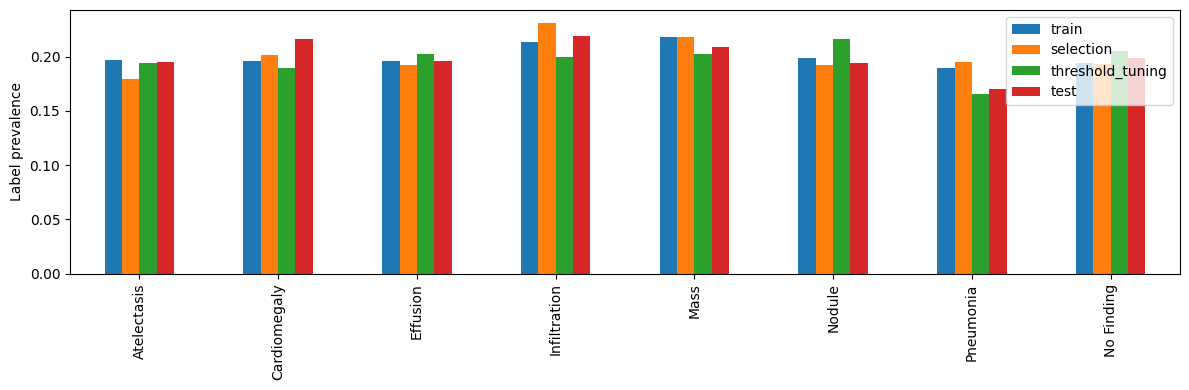

In [4]:
def group_holdout(frame, fraction, seed):
    splitter = GroupShuffleSplit(n_splits=1, test_size=fraction, random_state=seed)
    a, b = next(splitter.split(frame, groups=frame.patient_id))
    return frame.iloc[a].reset_index(drop=True), frame.iloc[b].reset_index(drop=True)

def original_group_split(frame, val_size, test_size, seed):
    trval, test = group_holdout(frame, test_size, seed)
    train, validation = group_holdout(trval, val_size / (1.0 - test_size), seed)
    return train, validation, test

def split_score(parts, frame, sizes, min_pos):
    overall = frame[CLASSES].mean().to_numpy()
    score = 0.0
    for part, target in zip(parts, sizes):
        score += np.abs(part[CLASSES].mean().to_numpy() - overall).sum()
        score += abs(len(part) / len(frame) - target)
        score += 10.0 * int((part[CLASSES].sum().to_numpy() < min_pos).any())
    return score

rng = np.random.default_rng(SEED)
best, best_score, best_seed = None, np.inf, None
for candidate in rng.integers(0, 2**31 - 1, size=CFG['split_candidates']):
    parts = original_group_split(df, 0.15, 0.15, int(candidate))
    score = split_score(parts, df, (0.70, 0.15, 0.15), CFG['min_positives_per_split'])
    if score < best_score:
        best, best_score, best_seed = parts, score, int(candidate)
train_df, original_val_df, test_df = best
assert (len(train_df), len(original_val_df), len(test_df)) == (5400, 1109, 1176), (
    'Original split counts differ; compare subset and metadata before training.')
select_df, tune_df = group_holdout(original_val_df, 1 / 3, SEED + 2)
PARTS = {'train':train_df, 'selection':select_df, 'threshold_tuning':tune_df, 'test':test_df}
SPLIT_DIR = OUT / 'splits'; SPLIT_DIR.mkdir(exist_ok=True)
overlap = {}
for a, left in PARTS.items():
    positives = left[CLASSES].sum()
    if ((positives == 0) | (positives == len(left))).any():
        raise ValueError(f'{a} lacks positive or negative examples for some classes. Fix the protocol before training.')
    for b, right in PARTS.items():
        if a < b:
            overlap[f'{a}:{b}:patients'] = len(set(left.patient_id) & set(right.patient_id))
            overlap[f'{a}:{b}:images'] = len(set(left.image) & set(right.image))
assert all(v == 0 for v in overlap.values())
assert sum(map(len, PARTS.values())) == len(df)
fingerprint_bytes = b''
for name, part in PARTS.items():
    part.to_csv(SPLIT_DIR / f'{name}.csv', index=False)
    fingerprint_bytes += name.encode() + part[['image','patient_id',*CLASSES]].to_csv(index=False).encode()
SPLIT_HASH = hashlib.sha256(fingerprint_bytes).hexdigest()
(OUT / 'split_report.json').write_text(json.dumps({'fingerprint':SPLIT_HASH, 'overlap':overlap, 'original_split_seed':best_seed,
    'original_split_score':best_score, 'original_validation_images':len(original_val_df)}, indent=2))
split_summary = pd.DataFrame({name:part[CLASSES].sum() for name,part in PARTS.items()})
split_summary.loc['images'] = [len(p) for p in PARTS.values()]
split_summary.loc['patients'] = [p.patient_id.nunique() for p in PARTS.values()]
split_summary.to_csv(OUT / 'split_summary.csv')
display(split_summary)
ax = pd.DataFrame({n:p[CLASSES].mean() for n,p in PARTS.items()}).plot.bar(figsize=(12,4))
ax.set_ylabel('Label prevalence'); plt.tight_layout(); plt.savefig(OUT/'class_prevalence.png'); plt.show()

## 4. Pretrained model and preprocessing

The full image is resized to 224 × 224 and repeated into RGB channels. We use the pretrained model's mean and standard deviation. Mild rotation, translation, zoom, brightness and contrast changes apply only to training. We avoid flips and large random crops. Eight sigmoid scores permit multiple findings in an image; a softmax would incorrectly force them to compete.

Positive weights are computed from training patients only and capped at 20. Weighted BCE reduces the dominance of negative labels, but its sigmoid outputs need not be calibrated disease probabilities. Threshold tuning adjusts decisions; it does **not** calibrate probabilities. The cap and learning rates are initial choices, not proven optimal hyperparameters.

In [5]:
def build_vit(pretrained):
    model = timm.create_model(CFG['model_name'], pretrained=pretrained, num_classes=len(CLASSES),
                              drop_path_rate=CFG['drop_path'])
    model.head = nn.Sequential(nn.Dropout(CFG['head_dropout']), nn.Linear(model.num_features,len(CLASSES)))
    return model

RESUME_PATH = Path(CFG['resume_from']) if CFG['resume_from'] else OUT/'latest.pt'
resume = torch.load(RESUME_PATH, map_location='cpu', weights_only=True) if RESUME_PATH.exists() else None
if resume:
    if resume['split_hash'] != SPLIT_HASH or resume['config'] != CFG:
        # resume_from is the only configuration field allowed to change.
        old_cfg = dict(resume['config']); new_cfg = dict(CFG)
        old_cfg.pop('resume_from',None); new_cfg.pop('resume_from',None)
        if resume['split_hash'] != SPLIT_HASH or old_cfg != new_cfg:
            raise ValueError('Resume data splits or training settings differ from the saved run.')
core = build_vit(pretrained=resume is None).to(DEVICE)
if resume: core.load_state_dict(resume['state_dict'])
DATA_CONFIG = timm.data.resolve_model_data_config(core)
PREPROCESS = {'size':CFG['image_size'], 'mean':list(DATA_CONFIG['mean']),
              'std':list(DATA_CONFIG['std']), 'interpolation':'bicubic', 'full_frame_resize':True}
normalize = T.Normalize(PREPROCESS['mean'], PREPROCESS['std'])
eval_transform = T.Compose([T.ToTensor(), normalize])
train_transform = T.Compose([
    T.RandomAffine(degrees=7, translate=(0.03,0.03), scale=(0.97,1.03),
                   interpolation=InterpolationMode.BILINEAR, fill=0),
    T.ColorJitter(brightness=0.08, contrast=0.08), T.ToTensor(), normalize,
])

class ChestDataset(Dataset):
    def __init__(self, frame, training=False):
        self.frame = frame.reset_index(drop=True)
        self.labels = self.frame[CLASSES].to_numpy(dtype=np.float32)
        self.transform = train_transform if training else eval_transform
        self.cache = None
    def __len__(self): return len(self.frame)
    def __getitem__(self, i):
        row = self.frame.iloc[i]
        if CFG['cache_images']:
            if self.cache is None:
                self.cache = np.memmap(CACHE_PATH, dtype='uint8', mode='r',
                                      shape=(len(df),CFG['image_size'],CFG['image_size']))
            im = Image.fromarray(np.array(self.cache[int(row.cache_index)], copy=True)).convert('RGB')
        else:
            with Image.open(row.path) as raw:
                im = raw.convert('L').resize((CFG['image_size'],CFG['image_size']),Image.Resampling.BICUBIC).convert('RGB')
        return self.transform(im), torch.from_numpy(self.labels[i])

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed); random.seed(worker_seed)

def make_loader(frame, training=False, epoch_seed=SEED):
    generator = torch.Generator().manual_seed(epoch_seed)
    return DataLoader(ChestDataset(frame, training), batch_size=BATCH, shuffle=training,
        num_workers=CFG['workers'], pin_memory=True, worker_init_fn=seed_worker,
        generator=generator, drop_last=False)

select_loader = make_loader(select_df)
train_eval_loader = make_loader(train_df)  # Unaugmented training scores after training.
positive = train_df[CLASSES].sum().to_numpy(dtype=np.float32)
POS_WEIGHT = np.minimum((len(train_df)-positive)/positive, CFG['max_pos_weight'])
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_WEIGHT,device=DEVICE),reduction='none')
pd.DataFrame({'class':CLASSES,'train_positives':positive,'positive_weight':POS_WEIGHT}).to_csv(OUT/'class_weights.csv',index=False)
model = nn.DataParallel(core,device_ids=list(range(GPU_COUNT))) if GPU_COUNT > 1 else core
print('Parameters:',sum(p.numel() for p in core.parameters()))
print('Preprocessing:',PREPROCESS)

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Parameters: 85804808
Preprocessing: {'size': 224, 'mean': [0.5, 0.5, 0.5], 'std': [0.5, 0.5, 0.5], 'interpolation': 'bicubic', 'full_frame_resize': True}


## 5. Training, early stopping, and saving

Start with the classifier, then train the last four transformer blocks, then optionally fine-tune the whole encoder at a smaller rate. Frozen blocks stay in evaluation mode. Each stage starts from the best validation checkpoint so far. AdamW excludes biases and normalization parameters from weight decay. Linear warmup followed by cosine decay and gradient clipping reduce abrupt updates.

The **exact macro validation ROC-AUC** chooses the checkpoint; early stopping ends a stage after three epochs without a meaningful gain. `best.pt` keeps the best observed checkpoint; `latest.pt` additionally holds optimizer, scaler, and RNG state for an epoch-boundary resume. At the training time limit, the current incomplete epoch is discarded and the latest complete epoch remains resumable. A fresh committed run cannot automatically retrieve a previous session's local output; attach that output and set `resume_from` to its `latest.pt`.

In [6]:
def atomic_torch_save(payload, path):
    path = Path(path); temporary = path.with_suffix(path.suffix+'.tmp')
    torch.save(payload, temporary); os.replace(temporary,path)

def cpu_state(): return {k:v.detach().cpu().clone() for k,v in core.state_dict().items()}

def checkpoint_metadata():
    return {'model_name':CFG['model_name'], 'classes':CLASSES, 'preprocessing':PREPROCESS,
            'config':CFG, 'environment':environment, 'split_hash':SPLIT_HASH,
            'positive_weights':POS_WEIGHT.tolist()}

def amp_context():
    return torch.autocast('cuda',dtype=torch.float16,enabled=CFG['amp'])

def metric_table(y, p, thresholds=0.5):
    pred = p >= np.asarray(thresholds)
    rows = []
    cms = multilabel_confusion_matrix(y,pred)
    for j,c in enumerate(CLASSES):
        tn,fp,fn,tp = cms[j].ravel()
        has_both = len(np.unique(y[:,j])) == 2
        precision = tp/(tp+fp) if tp+fp else 0.0
        recall = tp/(tp+fn) if tp+fn else 0.0
        rows.append({'class':c,'support':int(y[:,j].sum()),'prevalence':float(y[:,j].mean()),
            'precision':precision, 'recall':recall, 'f1':2*tp/(2*tp+fp+fn) if 2*tp+fp+fn else 0.0,
            'roc_auc':roc_auc_score(y[:,j],p[:,j]) if has_both else np.nan,
            'average_precision':average_precision_score(y[:,j],p[:,j]) if has_both else np.nan,
            'specificity':tn/(tn+fp) if tn+fp else np.nan,
            'tn':int(tn),'fp':int(fp),'fn':int(fn),'tp':int(tp)})
    table = pd.DataFrame(rows)
    summary = {f'macro_{m}':float(table[m].mean()) for m in ['precision','recall','f1','roc_auc','average_precision']}
    summary.update({'micro_f1':float(f1_score(y,pred,average='micro',zero_division=0)),
        'subset_accuracy':float(accuracy_score(y,pred)), 'label_accuracy':float((y==pred).mean()),
        'brier_mean':float(np.mean((y-p)**2)),
        'no_finding_disease_conflict_rate':float(np.mean(pred[:,-1] & pred[:,:-1].any(axis=1)))})
    return table,summary

@torch.inference_mode()
def predict(loader):
    model.eval(); ys=[]; ps=[]; total_loss=0.; count=0
    for x,y in loader:
        x=x.to(DEVICE,non_blocking=True); target=y.to(DEVICE,non_blocking=True)
        with amp_context(): logits=model(x)
        loss=criterion(logits.float(),target).mean()
        if not torch.isfinite(loss): raise FloatingPointError('Non-finite evaluation loss.')
        total_loss += loss.item()*len(x); count += len(x)
        ys.append(y.numpy()); ps.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.concatenate(ys),np.concatenate(ps),total_loss/count

def set_stage(stage_name):
    for p in core.parameters(): p.requires_grad_(stage_name=='full')
    for p in core.head.parameters(): p.requires_grad_(True)
    if stage_name=='last_blocks':
        for module in [*list(core.blocks)[-4:],core.norm]:
            for p in module.parameters(): p.requires_grad_(True)

def stage_train_mode(stage_name):
    model.train()
    if stage_name != 'full':
        core.eval(); core.head.train()
        if stage_name=='last_blocks':
            for module in [*list(core.blocks)[-4:],core.norm]: module.train()

def build_optimizer(stage):
    groups = {}
    for name,p in core.named_parameters():
        if not p.requires_grad: continue
        lr = stage['head_lr'] if name.startswith('head.') else stage['backbone_lr']
        decay = 0.0 if p.ndim <= 1 or name.endswith('bias') or name in {'cls_token','pos_embed'} else CFG['weight_decay']
        groups.setdefault((lr,decay),[]).append(p)
    return torch.optim.AdamW([{'params':params,'lr':lr,'weight_decay':decay} for (lr,decay),params in groups.items()])

def rng_state():
    n=np.random.get_state()
    return {'python':random.getstate(), 'numpy':[n[0],n[1].tolist(),n[2],n[3],n[4]],
            'torch':torch.get_rng_state(),'cuda':torch.cuda.get_rng_state_all()}

def restore_rng(state):
    random.setstate(state['python']); n=state['numpy']
    np.random.set_state((n[0],np.array(n[1],dtype=np.uint32),n[2],n[3],n[4]))
    torch.set_rng_state(state['torch']); torch.cuda.set_rng_state_all(state['cuda'])

BEST = OUT/'best.pt'; LATEST = OUT/'latest.pt'
best_auc = resume['best_auc'] if resume else -float('inf')
history = resume['history'] if resume else []
best_payload = resume['best_payload'] if resume else None
if best_payload: atomic_torch_save(best_payload,BEST)
resume_stage = resume['stage_index'] if resume else 0
resume_epoch = resume['next_epoch'] if resume else 0
start=time.perf_counter(); deadline=start+CFG['max_train_hours']*3600
halt=False; stopped_reason='completed_all_stages'

for stage_index,stage in enumerate(CFG['stages']):
    if stage_index < resume_stage: continue
    continue_stage = bool(resume and stage_index==resume_stage and resume_epoch>0)
    if not continue_stage and BEST.exists():
        core.load_state_dict(torch.load(BEST,map_location=DEVICE,weights_only=True)['state_dict'])
    set_stage(stage['name']); optimizer=build_optimizer(stage)
    updates=math.ceil(math.ceil(len(train_df)/BATCH)/CFG['accumulation_steps'])
    total_updates=updates*stage['epochs']; warmup=max(1,int(total_updates*CFG['warmup_fraction']))
    def lr_factor(step):
        if step < warmup: return (step+1)/warmup
        t=min(1.0,(step-warmup)/max(1,total_updates-warmup))
        return 0.1+0.9*0.5*(1+math.cos(math.pi*t))
    scheduler=torch.optim.lr_scheduler.LambdaLR(optimizer,lr_factor)
    scaler=torch.amp.GradScaler('cuda',enabled=CFG['amp'])
    stage_reference=-float('inf'); bad_epochs=0
    first_epoch=resume_epoch if continue_stage else 0
    if continue_stage:
        optimizer.load_state_dict(resume['optimizer']); scheduler.load_state_dict(resume['scheduler'])
        scaler.load_state_dict(resume['scaler']); restore_rng(resume['rng'])
        stage_reference=resume['stage_reference']; bad_epochs=resume['bad_epochs']
    print(stage['name'],'trainable parameters:',sum(p.numel() for p in core.parameters() if p.requires_grad))
    for epoch in range(first_epoch,stage['epochs']):
        epoch_start=time.perf_counter(); stage_train_mode(stage['name'])
        loader=make_loader(train_df,training=True,epoch_seed=SEED+100*stage_index+epoch)
        optimizer.zero_grad(set_to_none=True); loss_sum=0.; examples=0
        progress=tqdm(loader,desc=f'{stage["name"]} {epoch+1}/{stage["epochs"]}')
        for step,(x,y) in enumerate(progress):
            if time.perf_counter()>=deadline:
                halt=True; stopped_reason='training_time_budget'; break
            x=x.to(DEVICE,non_blocking=True); y=y.to(DEVICE,non_blocking=True)
            group_start=(step//CFG['accumulation_steps'])*CFG['accumulation_steps']
            group_examples=min(BATCH*CFG['accumulation_steps'],len(train_df)-group_start*BATCH)
            with amp_context(): logits=model(x)
            per_image=criterion(logits.float(),y).mean(dim=1)
            loss=per_image.sum()/group_examples  # Correct weighting of the final partial group.
            if not torch.isfinite(loss): raise FloatingPointError('Non-finite training loss; latest checkpoint is retained.')
            scaler.scale(loss).backward()
            if (step+1)%CFG['accumulation_steps']==0 or step+1==len(loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(core.parameters(),1.0)
                previous_scale=scaler.get_scale()
                scaler.step(optimizer); scaler.update()
                if scaler.get_scale()>=previous_scale: scheduler.step()
                optimizer.zero_grad(set_to_none=True)
            loss_sum+=per_image.detach().sum().item(); examples+=len(x)
            progress.set_postfix(loss=loss_sum/examples)
        if halt: break
        y_val,p_val,val_loss=predict(select_loader)
        _,scores=metric_table(y_val,p_val)
        auc=scores['macro_roc_auc']
        if not math.isfinite(auc): raise FloatingPointError('Undefined validation AUC.')
        row={'stage':stage['name'],'epoch':epoch+1,'train_augmented_loss':loss_sum/examples,
             'val_loss':val_loss,'val_auc':auc,'val_ap':scores['macro_average_precision'],
             'val_f1_05':scores['macro_f1'],'seconds':time.perf_counter()-epoch_start}
        history.append(row); print(row)
        pd.DataFrame(history).to_csv(OUT/'history.csv',index=False)
        if auc>best_auc:
            best_auc=auc
            best_payload={**checkpoint_metadata(),'state_dict':cpu_state(),'best_val_auc':auc,
                          'best_stage':stage['name'],'best_epoch_in_stage':epoch+1}
            atomic_torch_save(best_payload,BEST)
        if auc>stage_reference+CFG['min_delta']:
            stage_reference=auc; bad_epochs=0
        else: bad_epochs+=1
        stage_done=bad_epochs>=CFG['patience'] or epoch+1==stage['epochs']
        atomic_torch_save({**checkpoint_metadata(),'state_dict':cpu_state(),
            'optimizer':optimizer.state_dict(),'scheduler':scheduler.state_dict(),'scaler':scaler.state_dict(),
            'rng':rng_state(),'stage_index':stage_index+1 if stage_done else stage_index,
            'next_epoch':0 if stage_done else epoch+1,'stage_reference':stage_reference,
            'bad_epochs':bad_epochs,'best_auc':best_auc,'best_payload':best_payload,'history':history},LATEST)
        if stage_done: break
    if halt: break
    resume=None
if not BEST.exists():
    raise RuntimeError('No full epoch completed. Increase max_train_hours and restart.')
selected=torch.load(BEST,map_location=DEVICE,weights_only=True)
core.load_state_dict(selected['state_dict']); model.eval()
train_summary={'stop_reason':stopped_reason,'epochs_completed':len(history),
    'this_session_train_hours':(time.perf_counter()-start)/3600,'best_val_auc':selected['best_val_auc'],
    'best_stage':selected['best_stage'],'best_epoch_in_stage':selected['best_epoch_in_stage'],
    'all_stages_completed':not halt}
(OUT/'training_summary.json').write_text(json.dumps(train_summary,indent=2))
display(pd.DataFrame(history)); print(train_summary)

head trainable parameters: 6152


head 1/2:   0%|          | 0/338 [00:00<?, ?it/s]

{'stage': 'head', 'epoch': 1, 'train_augmented_loss': 1.2706586274394283, 'val_loss': 1.1166541550399822, 'val_auc': 0.6169563540223616, 'val_ap': 0.2831589329053976, 'val_f1_05': 0.30525269989824266, 'seconds': 42.20900187599989}


head 2/2:   0%|          | 0/338 [00:00<?, ?it/s]

{'stage': 'head', 'epoch': 2, 'train_augmented_loss': 1.182702448103163, 'val_loss': 1.0800259681748434, 'val_auc': 0.6355418393897316, 'val_ap': 0.30244346715071907, 'val_f1_05': 0.33725517696926144, 'seconds': 57.448562978000155}
last_blocks trainable parameters: 28359176


...

{'stage': 'full', 'epoch': 7, 'train_augmented_loss': 0.9751053433948093, 'val_loss': 0.9433977972584134, 'val_auc': 0.7491662035780735, 'val_ap': 0.44479763630583524, 'val_f1_05': 0.4654811211068396, 'seconds': 118.46665004200008}


full 8/8:   0%|          | 0/338 [00:00<?, ?it/s]

{'stage': 'full', 'epoch': 8, 'train_augmented_loss': 0.9640260104779844, 'val_loss': 0.9441324519526406, 'val_auc': 0.7490379519747621, 'val_ap': 0.44471707238015057, 'val_f1_05': 0.46899431092470245, 'seconds': 57.73588116399969}


,stage,epoch,train_augmented_loss,val_loss,val_auc,val_ap,val_f1_05,seconds
0,head,1,1.270659,1.116654,0.616956,0.283159,0.305253,42.209002
1,head,2,1.182702,1.080026,0.635542,0.302443,0.337255,57.448563
2,last_blocks,1,1.217138,1.056686,0.676231,0.345244,0.378699,42.694178
3,last_blocks,2,1.146588,1.014287,0.701938,0.379355,0.412495,42.901621
4,last_blocks,3,1.088536,1.020461,0.710567,0.391012,0.407454,103.416053
5,last_blocks,4,1.050540,0.999203,0.716471,0.398911,0.427460,42.965930
6,last_blocks,5,1.030296,0.988482,0.718565,0.402192,0.436454,42.742772
7,full,1,1.075163,1.023303,0.723015,0.412136,0.414079,118.013131
8,full,2,1.052934,0.984585,0.733058,0.424590,0.431567,57.849340
9,full,3,1.026341,0.956883,0.742577,0.434534,0.465982,57.518463


{'stop_reason': 'completed_all_stages', 'epochs_completed': 15, 'this_session_train_hours': 0.29336986264805553, 'best_val_auc': 0.7491662035780735, 'best_stage': 'full', 'best_epoch_in_stage': 7, 'all_stages_completed': True}


## 6. Choose decision thresholds using tuning validation

For each label we choose the threshold with the highest F1 on threshold-tuning patients. F1 balances precision and recall equally; a sensitivity-focused objective would need a different predeclared rule. We also retain results at 0.5. Tuning changes precision, recall and F1, but does not change ROC-AUC or average precision, which use continuous scores. `No Finding` is evaluated independently, so contradictory outputs are counted rather than silently suppressed.

In [7]:
y_tune,p_tune,_=predict(make_loader(tune_df))
thresholds=[]; threshold_rows=[]
for j,c in enumerate(CLASSES):
    precision,recall,candidates=precision_recall_curve(y_tune[:,j],p_tune[:,j])
    f1=2*precision[:-1]*recall[:-1]/np.maximum(precision[:-1]+recall[:-1],1e-12)
    winners=np.flatnonzero(np.isclose(f1,f1.max(),rtol=0,atol=1e-12))
    # Deterministic tie break: threshold nearest 0.5.
    idx=winners[np.argmin(np.abs(candidates[winners]-0.5))]
    threshold=float(candidates[idx]); thresholds.append(threshold)
    threshold_rows.append({'class':c,'threshold':threshold,'tuning_f1':float(f1[idx]),
                           'tuning_precision':float(precision[idx]),'tuning_recall':float(recall[idx])})
thresholds=np.array(thresholds)
pd.DataFrame(threshold_rows).to_csv(OUT/'thresholds.csv',index=False)
(OUT/'thresholds.json').write_text(json.dumps(dict(zip(CLASSES,thresholds.tolist())),indent=2))
np.savez_compressed(OUT/'tuning_predictions.npz',labels=y_tune,scores=p_tune,images=tune_df.image.to_numpy(dtype=str))
display(pd.DataFrame(threshold_rows))

,class,threshold,tuning_f1,tuning_precision,tuning_recall
0,Atelectasis,0.597490,0.497041,0.437500,0.575342
1,Cardiomegaly,0.601067,0.607595,0.551724,0.676056
2,Effusion,0.530100,0.497512,0.400000,0.657895
3,Infiltration,0.548674,0.532710,0.410072,0.760000
4,Mass,0.402744,0.497959,0.360947,0.802632
5,Nodule,0.681621,0.480519,0.506849,0.456790
6,Pneumonia,0.587529,0.460606,0.368932,0.612903
7,No Finding,0.626353,0.502618,0.421053,0.623377


## 7. Held-out test evaluation and uncertainty

**Precision** = TP/(TP+FP): how many predicted positives carry the label. **Recall** = TP/(TP+FN): how many labeled positives are found. **F1** = 2TP/(2TP+FP+FN): their balance. **Specificity** = TN/(TN+FP): how many negatives are rejected. **Support** counts positive images; **prevalence** is their fraction. TP/FP/FN/TN are agreement with NIH labels, not adjudicated diagnoses.

**ROC-AUC** measures positive-vs-negative ranking over thresholds; 0.5 is chance ranking and 1 is perfect ranking. It is not accuracy or the probability that a patient has disease. **Average precision (AP)** summarizes precision across recall levels and is useful with rare positives; prevalence provides the reference for uninformative random ranking. AP is not trapezoidal PR-AUC. [scikit-learn metrics](https://scikit-learn.org/stable/api/sklearn.metrics.html), [AP definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).

**Macro** averages each class equally; **micro F1** pools TP/FP/FN. **Label accuracy** counts individual label decisions and can be inflated by negatives; **subset accuracy** requires all eight labels to match for an image. **Weighted loss** is the optimization objective, not a percentage, and cannot be compared across different weights. **Brier score** is mean squared score error (lower is better); weighting the training loss can impair calibration. **Conflict rate** counts simultaneous `No Finding` and disease decisions. **Milliseconds per image** below is amortized throughput including loading and preprocessing, not isolated single-image GPU latency.

Confidence intervals resample **patients with replacement**, keeping all images for each patient together. They describe test-sample variability conditional on this trained model, fixed thresholds, and population; they do not capture variability between training runs. We report class intervals and macro ROC-AUC, macro AP and macro F1 intervals. Undefined AUC replicates are skipped and their counts recorded.

In [8]:
test_loader=make_loader(test_df)
# Warm the GPU; timing includes the complete data pipeline.
with torch.inference_mode(),amp_context():
    model(next(iter(test_loader))[0].to(DEVICE))
torch.cuda.synchronize(); inference_start=time.perf_counter()
y_test,p_test,test_loss=predict(test_loader)
torch.cuda.synchronize()
ms_per_image=1000*(time.perf_counter()-inference_start)/len(test_df)
table_05,summary_05=metric_table(y_test,p_test,0.5)
table_tuned,summary_tuned=metric_table(y_test,p_test,thresholds)
table_05.to_csv(OUT/'test_per_class_05.csv',index=False)
table_tuned['threshold']=thresholds
table_tuned.to_csv(OUT/'test_per_class_tuned.csv',index=False)
np.savez_compressed(OUT/'test_predictions.npz',labels=y_test,scores=p_test,
    images=test_df.image.to_numpy(dtype=str),patient_ids=test_df.patient_id.to_numpy(dtype=str))
test_summary={'at_05':summary_05,'at_tuned_thresholds':summary_tuned,
              'weighted_bce':test_loss,'pipeline_ms_per_image':ms_per_image,'images':len(test_df)}
(OUT/'test_metrics.json').write_text(json.dumps(test_summary,indent=2))
display(table_tuned.round(4)); display(pd.DataFrame({'threshold_05':summary_05,'tuned':summary_tuned}))

def cluster_bootstrap(y,p,patients,thresholds,repeats,seed):
    rng=np.random.default_rng(seed)
    patient_groups=list(pd.Series(np.arange(len(patients))).groupby(np.asarray(patients)).apply(list))
    per_class={m:[] for m in ['roc_auc','average_precision','f1']}
    for _ in tqdm(range(repeats),desc='Patient bootstrap'):
        idx=np.concatenate([patient_groups[i] for i in rng.integers(0,len(patient_groups),size=len(patient_groups))])
        table,_=metric_table(y[idx],p[idx],thresholds)
        for m in per_class: per_class[m].append(table[m].to_numpy())
    rows=[]
    for m,values in per_class.items():
        a=np.array(values)
        for j,c in enumerate(CLASSES):
            valid=a[:,j][np.isfinite(a[:,j])]
            lo,hi=np.quantile(valid,[.025,.975]) if len(valid) else (np.nan,np.nan)
            rows.append({'class':c,'metric':m,'ci_low':float(lo),'ci_high':float(hi),'valid_repeats':len(valid)})
        # Require all classes to be defined in a replicate for a macro interval.
        valid=a[np.isfinite(a).all(axis=1)].mean(axis=1)
        lo,hi=np.quantile(valid,[.025,.975]) if len(valid) else (np.nan,np.nan)
        rows.append({'class':'macro','metric':m,'ci_low':float(lo),'ci_high':float(hi),'valid_repeats':len(valid)})
    return pd.DataFrame(rows)

intervals=cluster_bootstrap(y_test,p_test,test_df.patient_id.to_numpy(),thresholds,
                           CFG['bootstrap_repeats'],SEED+99)
intervals.to_csv(OUT/'test_patient_bootstrap.csv',index=False)
display(intervals)

,class,support,prevalence,precision,recall,f1,roc_auc,average_precision,specificity,tn,fp,fn,tp,threshold
0,Atelectasis,230,0.1956,0.4091,0.5087,0.4535,0.7685,0.4334,0.8214,777,169,113,117,0.5975
1,Cardiomegaly,255,0.2168,0.5315,0.7608,0.6258,0.8747,0.6843,0.8143,750,171,61,194,0.6011
2,Effusion,231,0.1964,0.3760,0.6104,0.4653,0.7612,0.4554,0.7524,711,234,90,141,0.5301
3,Infiltration,258,0.2194,0.3555,0.5814,0.4412,0.6898,0.3524,0.7037,646,272,108,150,0.5487
4,Mass,246,0.2092,0.3684,0.7398,0.4919,0.7515,0.4292,0.6645,618,312,64,182,0.4027
5,Nodule,229,0.1947,0.4118,0.3668,0.3880,0.7070,0.3863,0.8733,827,120,145,84,0.6816
6,Pneumonia,200,0.1701,0.3133,0.4950,0.3837,0.6935,0.3333,0.7777,759,217,101,99,0.5875
7,No Finding,234,0.1990,0.4256,0.6111,0.5018,0.7365,0.4333,0.7951,749,193,91,143,0.6264


,threshold_05,tuned
macro_precision,0.359406,0.398890
macro_recall,0.674664,0.584253
macro_f1,0.465754,0.468897
macro_roc_auc,0.747826,0.747826
macro_average_precision,0.438443,0.438443
micro_f1,0.465593,0.474258
subset_accuracy,0.052721,0.126701
label_accuracy,0.689626,0.738414
brier_mean,0.201676,0.201676
no_finding_disease_conflict_rate,0.371599,0.168367


Patient bootstrap:   0%|          | 0/200 [00:00<?, ?it/s]

,class,metric,ci_low,ci_high,valid_repeats
0,Atelectasis,roc_auc,0.728063,0.802403,200
1,Cardiomegaly,roc_auc,0.832125,0.903136,200
2,Effusion,roc_auc,0.725154,0.799559,200
3,Infiltration,roc_auc,0.646249,0.725123,200
4,Mass,roc_auc,0.712839,0.786852,200
5,Nodule,roc_auc,0.664578,0.741424,200
6,Pneumonia,roc_auc,0.644981,0.743111,200
7,No Finding,roc_auc,0.702299,0.769213,200
8,macro,roc_auc,0.731558,0.763182,200
9,Atelectasis,average_precision,0.360587,0.511634,200


## 8. Curves, calibration, subgroups, and error examples

Training loss measured with augmentation and dropout is not directly comparable to evaluation loss. We therefore score the selected model on unaugmented training and selection patients as well. A large training-versus-validation gap suggests overfitting; a single gap cannot identify its cause. Subgroup results by view and gender are descriptive and include support. Small or single-class subgroups produce undefined AUCs. Error examples use NIH labels and should be reviewed before attributing failures to anatomy, label noise, or image artifacts.

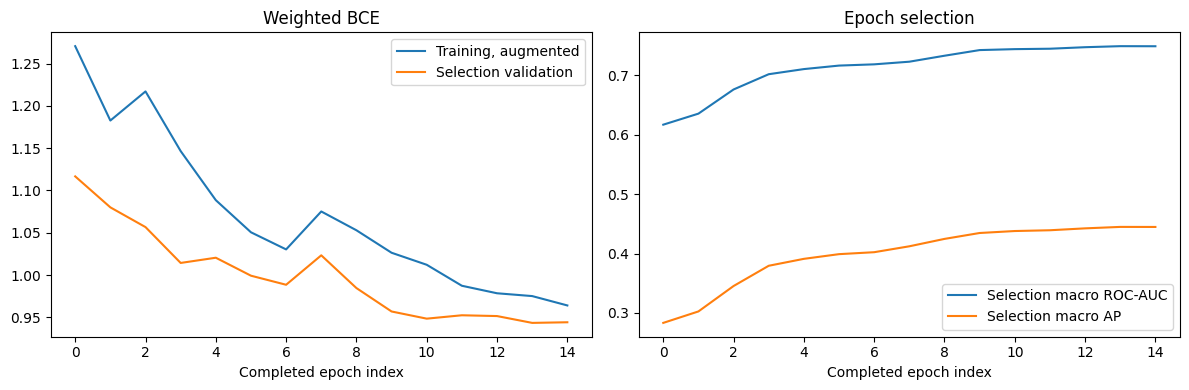

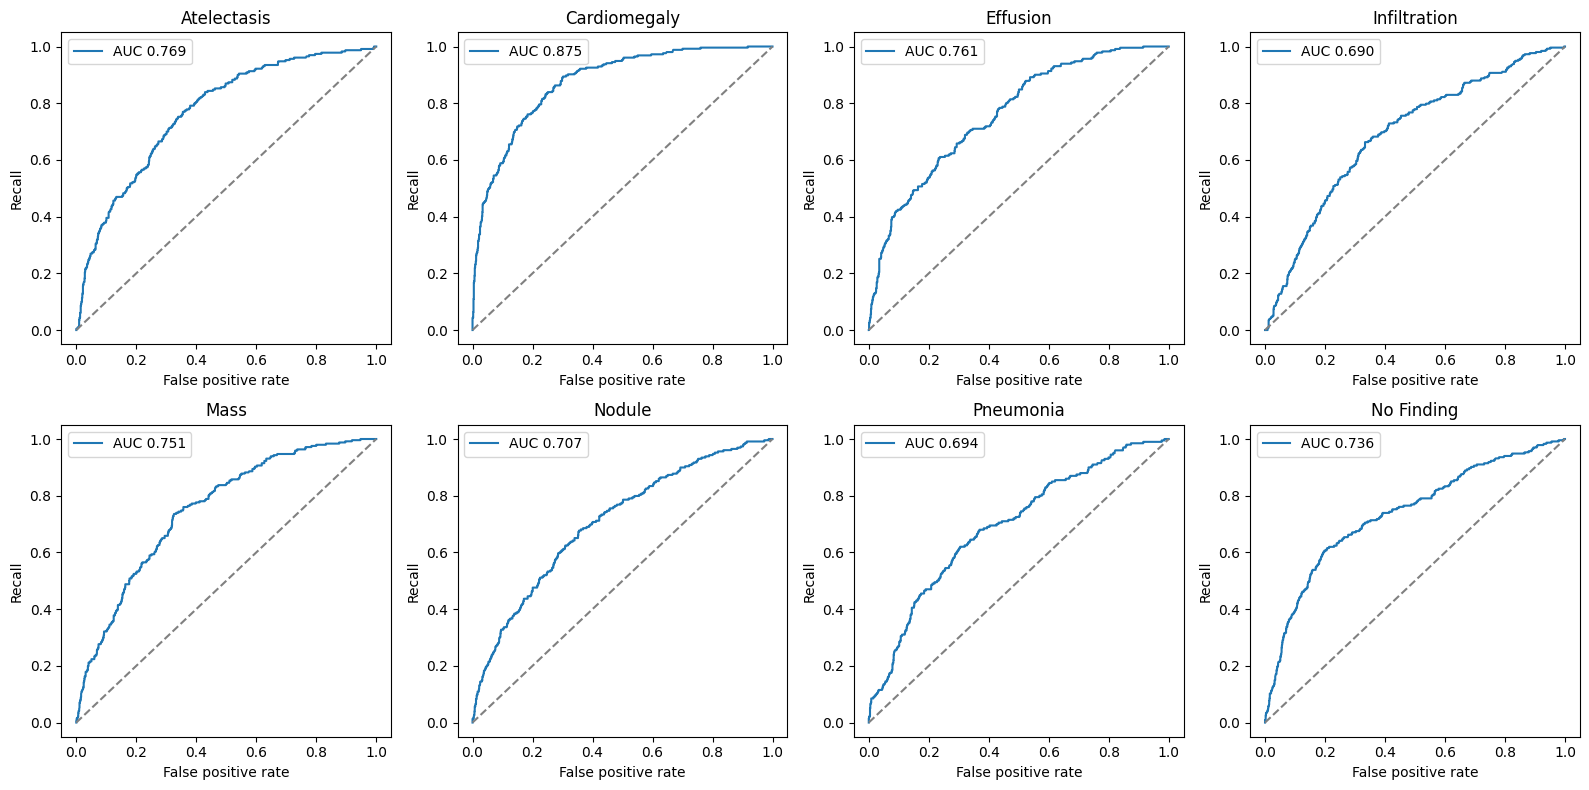

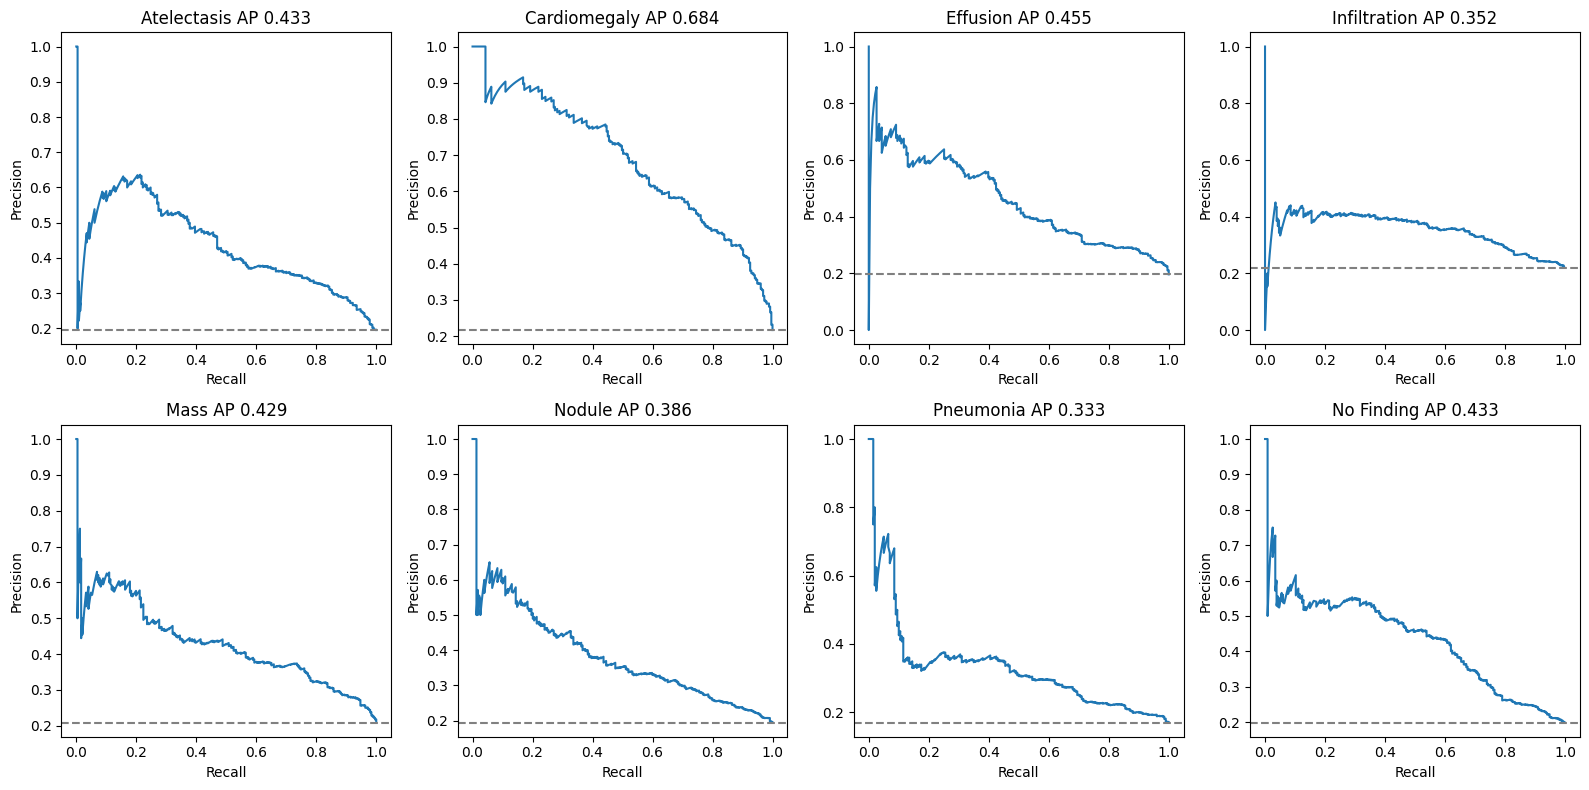

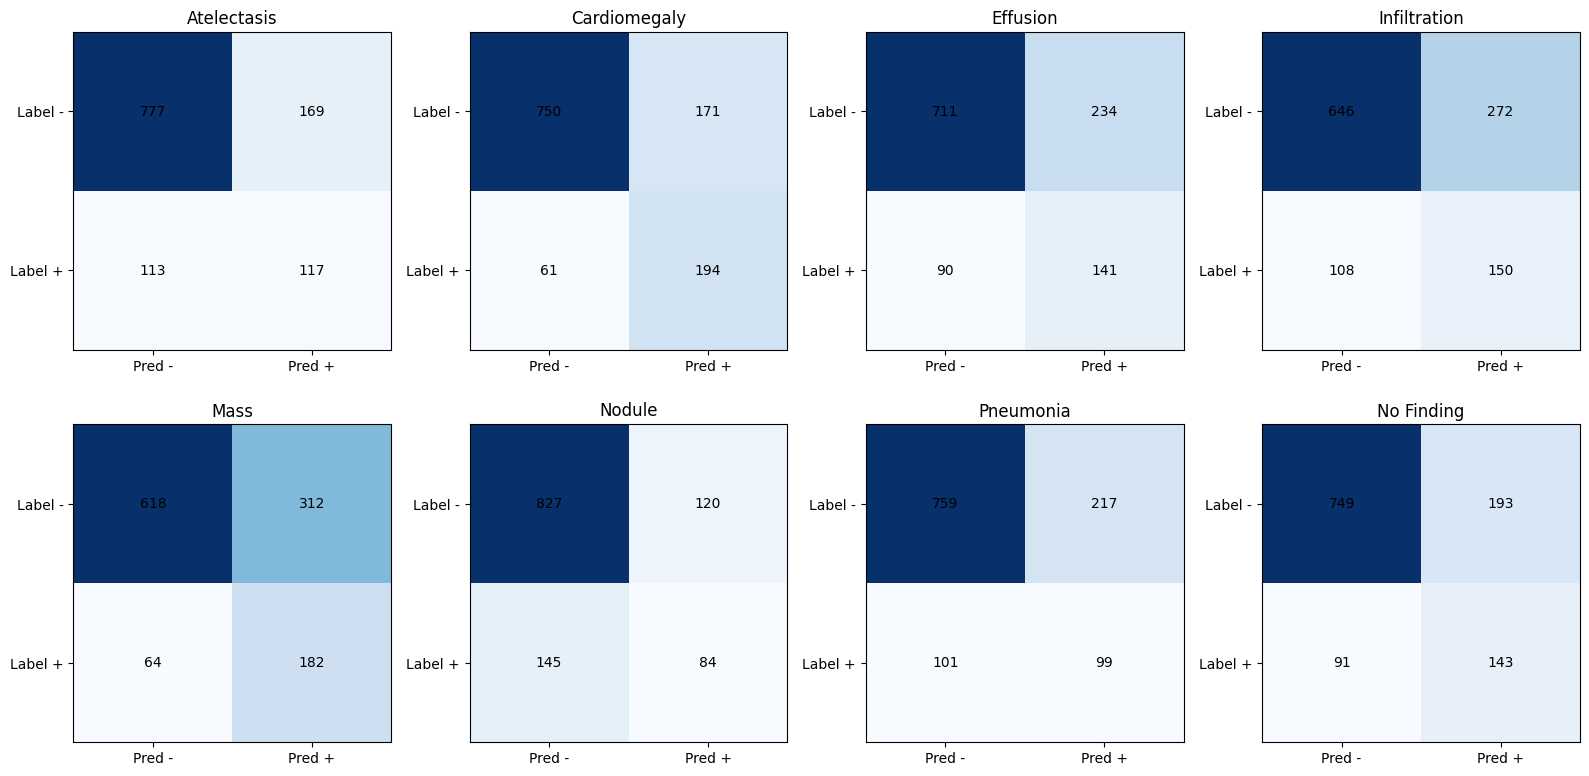

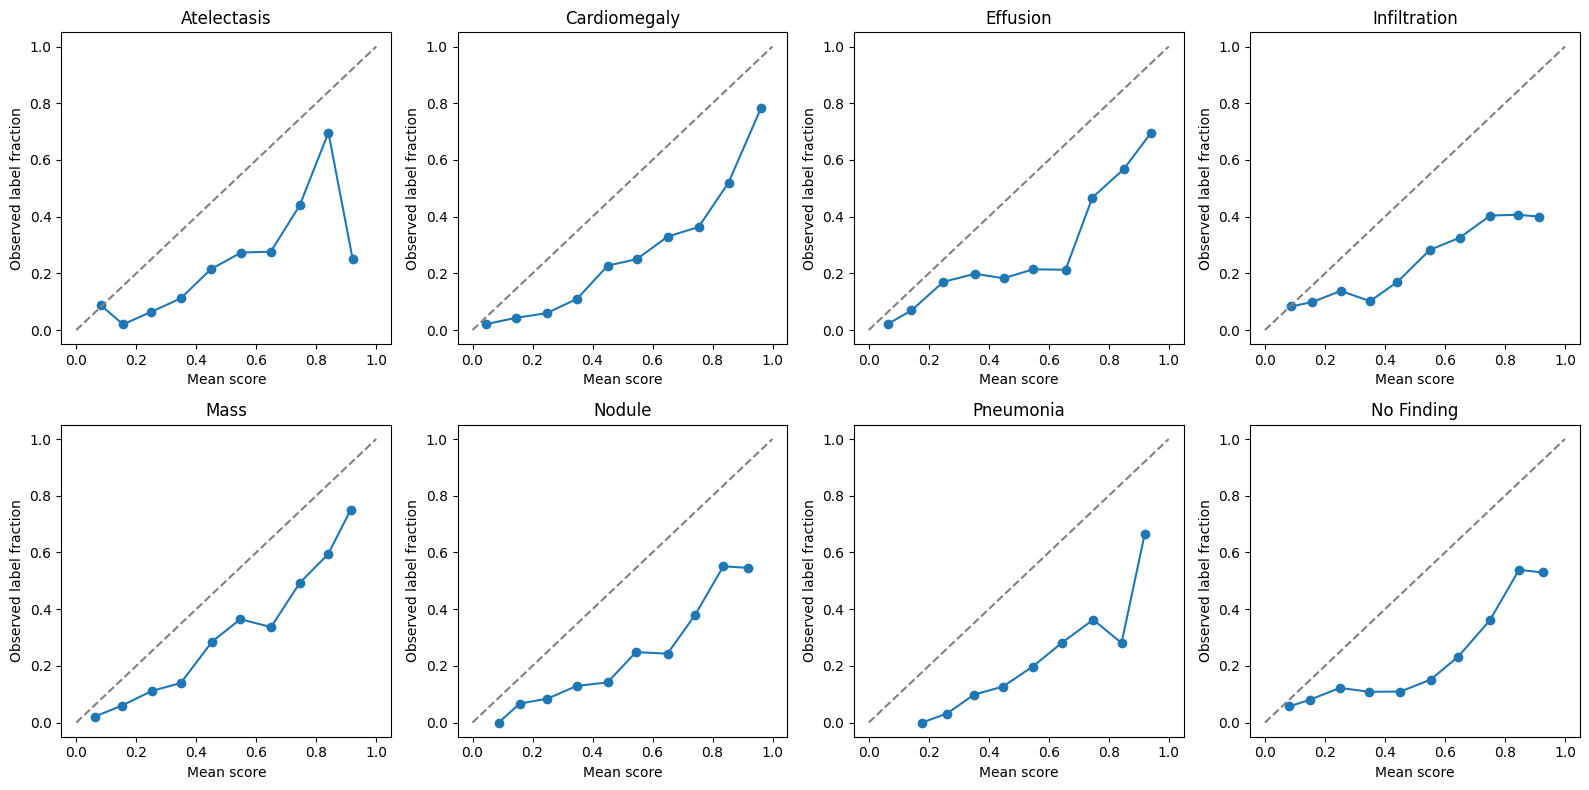

,train_unaugmented,selection,test
macro_precision,0.433073,0.394319,0.398890
macro_recall,0.622331,0.574513,0.584253
macro_f1,0.504429,0.463516,0.468897
macro_roc_auc,0.784161,0.749166,0.747826
macro_average_precision,0.495712,0.444798,0.438443
micro_f1,0.506503,0.467604,0.474258
subset_accuracy,0.144259,0.122616,0.126701
label_accuracy,0.755833,0.735525,0.738414
brier_mean,0.190768,0.201963,0.201676
no_finding_disease_conflict_rate,0.161296,0.162125,0.168367


,class,support,prevalence,precision,recall,f1,roc_auc,average_precision,specificity,tn,fp,fn,tp,group_column,group_value,images
0,Atelectasis,114,0.169,0.382,0.412,0.397,0.755,0.379,0.864,483,76,67,47,View Position,PA,673
1,Cardiomegaly,147,0.218,0.603,0.816,0.694,0.917,0.767,0.850,447,79,27,120,View Position,PA,673
2,Effusion,117,0.174,0.403,0.547,0.464,0.782,0.456,0.829,461,95,53,64,View Position,PA,673
3,Infiltration,119,0.177,0.328,0.345,0.336,0.652,0.311,0.848,470,84,78,41,View Position,PA,673
4,Mass,146,0.217,0.381,0.815,0.520,0.781,0.482,0.634,334,193,27,119,View Position,PA,673
5,Nodule,148,0.220,0.400,0.405,0.403,0.683,0.398,0.829,435,90,88,60,View Position,PA,673
6,Pneumonia,87,0.129,0.306,0.253,0.277,0.684,0.236,0.915,536,50,65,22,View Position,PA,673
7,No Finding,151,0.224,0.435,0.735,0.547,0.758,0.473,0.724,378,144,40,111,View Position,PA,673
8,Atelectasis,116,0.231,0.429,0.603,0.502,0.777,0.502,0.760,294,93,46,70,View Position,AP,503
9,Cardiomegaly,108,0.215,0.446,0.685,0.540,0.801,0.547,0.767,303,92,34,74,View Position,AP,503


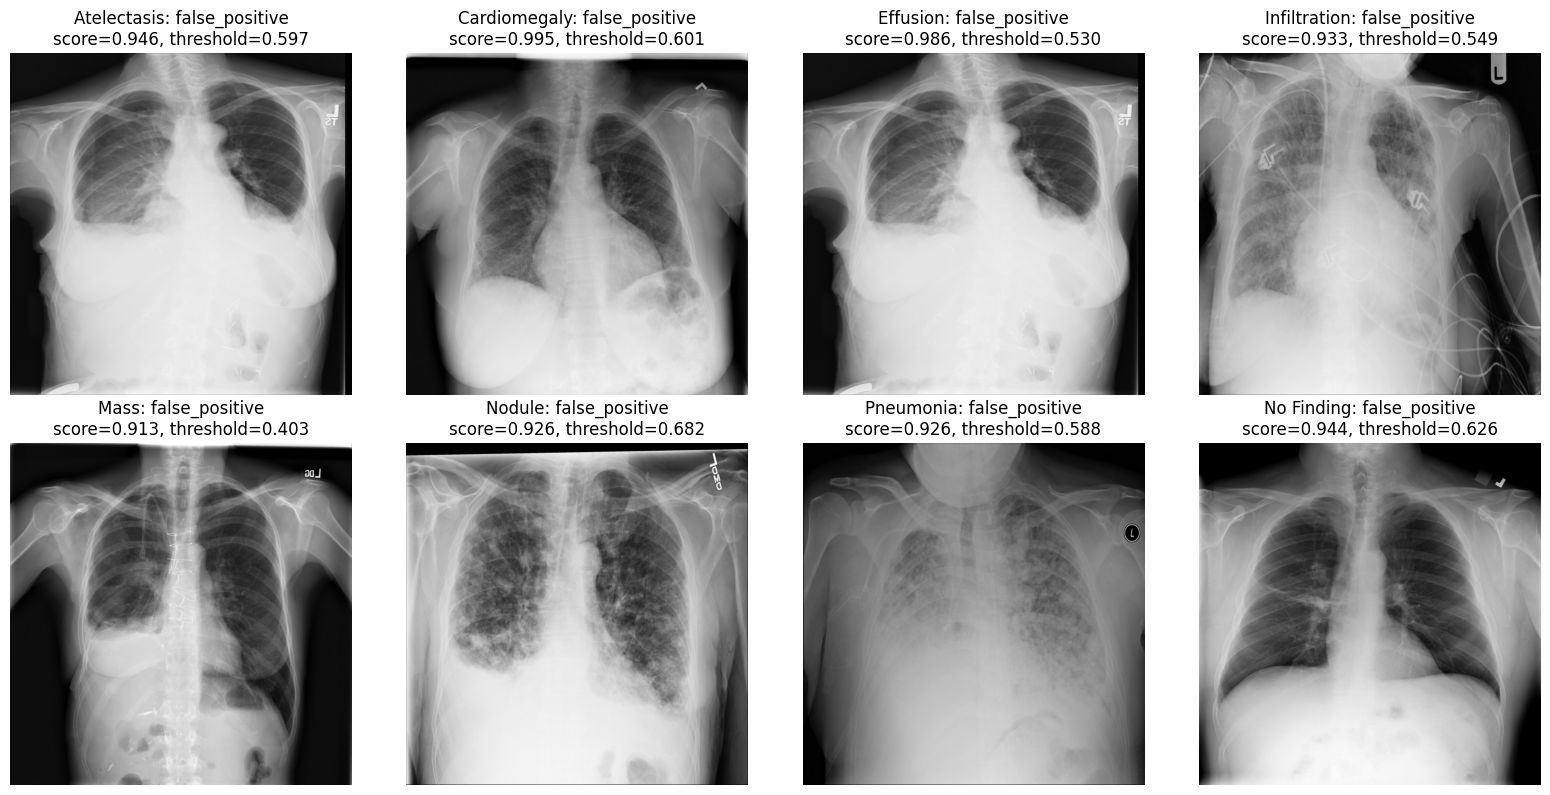

In [9]:
hist=pd.DataFrame(history)
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(hist.train_augmented_loss,label='Training, augmented')
axes[0].plot(hist.val_loss,label='Selection validation'); axes[0].set_title('Weighted BCE'); axes[0].legend()
axes[1].plot(hist.val_auc,label='Selection macro ROC-AUC'); axes[1].plot(hist.val_ap,label='Selection macro AP')
axes[1].set_title('Epoch selection'); axes[1].legend()
for ax in axes: ax.set_xlabel('Completed epoch index')
plt.tight_layout(); plt.savefig(OUT/'training_curves.png'); plt.show()

fig,axes=plt.subplots(2,4,figsize=(16,8))
for j,ax in enumerate(axes.flat):
    fpr,tpr,_=roc_curve(y_test[:,j],p_test[:,j]); ax.plot(fpr,tpr,label=f'AUC {table_tuned.iloc[j].roc_auc:.3f}')
    ax.plot([0,1],[0,1],'--',color='gray'); ax.set_title(CLASSES[j]); ax.set_xlabel('False positive rate'); ax.set_ylabel('Recall'); ax.legend()
plt.tight_layout(); plt.savefig(OUT/'roc_curves.png'); plt.show()
fig,axes=plt.subplots(2,4,figsize=(16,8))
for j,ax in enumerate(axes.flat):
    precision,recall,_=precision_recall_curve(y_test[:,j],p_test[:,j]); ax.plot(recall,precision)
    ax.axhline(y_test[:,j].mean(),ls='--',color='gray'); ax.set_title(f'{CLASSES[j]} AP {table_tuned.iloc[j].average_precision:.3f}')
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
plt.tight_layout(); plt.savefig(OUT/'precision_recall_curves.png'); plt.show()

fig,axes=plt.subplots(2,4,figsize=(16,8))
cms=multilabel_confusion_matrix(y_test,p_test>=thresholds)
for j,ax in enumerate(axes.flat):
    ax.imshow(cms[j],cmap='Blues'); ax.set_title(CLASSES[j]); ax.set_xticks([0,1],['Pred -','Pred +']); ax.set_yticks([0,1],['Label -','Label +'])
    for (r,c),v in np.ndenumerate(cms[j]): ax.text(c,r,str(v),ha='center',va='center',color='black')
plt.tight_layout(); plt.savefig(OUT/'confusion_matrices.png'); plt.show()

calibration_rows=[]
fig,axes=plt.subplots(2,4,figsize=(16,8))
for j,ax in enumerate(axes.flat):
    bins=np.minimum((p_test[:,j]*10).astype(int),9)
    for b in range(10):
        mask=bins==b
        if mask.any(): calibration_rows.append({'class':CLASSES[j],'bin':b,'count':int(mask.sum()),
            'mean_score':float(p_test[mask,j].mean()),'observed_fraction':float(y_test[mask,j].mean())})
    rows=pd.DataFrame([r for r in calibration_rows if r['class']==CLASSES[j]])
    ax.plot(rows.mean_score,rows.observed_fraction,'o-'); ax.plot([0,1],[0,1],'--',color='gray')
    ax.set_title(CLASSES[j]); ax.set_xlabel('Mean score'); ax.set_ylabel('Observed label fraction')
pd.DataFrame(calibration_rows).to_csv(OUT/'calibration_bins.csv',index=False)
plt.tight_layout(); plt.savefig(OUT/'calibration_curves.png'); plt.show()

comparison={}
for name,loader in [('train_unaugmented',train_eval_loader),('selection',select_loader)]:
    y,p,loss=predict(loader); _,s=metric_table(y,p,thresholds); s['weighted_bce']=loss
    comparison[name]=s
comparison['test']=dict(summary_tuned,weighted_bce=test_loss)
pd.DataFrame(comparison).to_csv(OUT/'generalization.csv')
display(pd.DataFrame(comparison))

subgroups=[]
for column in ['View Position','Patient Gender']:
    if column not in test_df: continue
    for value in test_df[column].dropna().unique():
        mask=(test_df[column]==value).to_numpy()
        table,_=metric_table(y_test[mask],p_test[mask],thresholds)
        table['group_column']=column; table['group_value']=str(value); table['images']=int(mask.sum())
        subgroups.append(table)
if subgroups:
    subgroup_table=pd.concat(subgroups,ignore_index=True)
    subgroup_table.to_csv(OUT/'test_subgroups.csv',index=False); display(subgroup_table.round(3))

errors=[]
for j,c in enumerate(CLASSES):
    pred=p_test[:,j]>=thresholds[j]
    for error,mask,descending in [('false_positive',pred & (y_test[:,j]==0),True),
                                  ('false_negative',~pred & (y_test[:,j]==1),False)]:
        candidates=np.flatnonzero(mask)
        candidates=candidates[np.argsort(p_test[candidates,j])]
        if descending: candidates=candidates[::-1]
        for i in candidates[:5]:
            errors.append({'class':c,'error':error,'image':test_df.iloc[i].image,
                'path':test_df.iloc[i].path,'patient_id':test_df.iloc[i].patient_id,
                'label':int(y_test[i,j]),'score':float(p_test[i,j]),'threshold':float(thresholds[j])})
pd.DataFrame(errors).to_csv(OUT/'error_examples.csv',index=False)
fig,axes=plt.subplots(2,4,figsize=(16,8))
for c,ax in zip(CLASSES,axes.flat):
    example=next((r for r in errors if r['class']==c),None)
    if example:
        with Image.open(example['path']) as im: ax.imshow(im.convert('L'),cmap='gray')
        ax.set_title(f'{c}: {example["error"]}\nscore={example["score"]:.3f}, threshold={example["threshold"]:.3f}')
    ax.axis('off')
plt.tight_layout(); plt.savefig(OUT/'error_gallery.png'); plt.show()

## 9. Save the inference model, verify reloading, and explain the actual results

`model.pt` contains the selected weights, architecture, class order, normalization and decision thresholds. `best.pt` records epoch selection, and `latest.pt` supports training resumption. Loading the inference package uses `pretrained=False`, so inference does not download ImageNet weights. The reload check compares outputs on the same real images. An archive excludes the large resume checkpoint and image cache; individual checkpoint files remain available as outputs.

The generated report explains observed precision/recall/F1 using TP/FP/FN counts and compares class AUCs, prevalence, calibration and generalization. Potential causes are explicitly labeled as hypotheses. Demonstrating that an enhancement caused a gain requires a matched split, controlled ablations, and ideally multiple seeds. This notebook is a single configured experiment and does not guarantee a better score.

In [10]:
inference_payload={**checkpoint_metadata(),'state_dict':cpu_state(),
    'thresholds':thresholds.tolist(),'best_val_auc':selected['best_val_auc'],
    'best_stage':selected['best_stage'],'best_epoch_in_stage':selected['best_epoch_in_stage']}
atomic_torch_save(inference_payload,OUT/'model.pt')

def load_inference_model(path,device='cpu'):
    bundle=torch.load(path,map_location=device,weights_only=True)
    restored=timm.create_model(bundle['model_name'],pretrained=False,num_classes=len(bundle['classes']),
                              drop_path_rate=bundle['config']['drop_path'])
    restored.head=nn.Sequential(nn.Dropout(bundle['config']['head_dropout']),
                               nn.Linear(restored.num_features,len(bundle['classes'])))
    restored.load_state_dict(bundle['state_dict']); restored.to(device).eval()
    prep=bundle['preprocessing']
    transform=T.Compose([T.Resize((prep['size'],prep['size']),interpolation=InterpolationMode.BICUBIC),
                         T.ToTensor(),T.Normalize(prep['mean'],prep['std'])])
    return restored,transform,bundle

restored,_,bundle=load_inference_model(OUT/'model.pt',DEVICE)
probe=next(iter(test_loader))[0][:2].to(DEVICE)
with torch.inference_mode():
    expected=core(probe).float(); actual=restored(probe).float()
torch.testing.assert_close(expected,actual,rtol=1e-5,atol=1e-5)
del restored; torch.cuda.empty_cache()
(OUT/'reload_check.json').write_text(json.dumps({'passed':True,'max_logit_difference':float((expected-actual).abs().max())}))

lines=['# Vision Transformer: actual run report','',
    f'Original subset images: {len(df):,}; patients: {df.patient_id.nunique():,}; full PNG storage: {audit["image_gib"]:.2f} GiB.',
    f'Test images: {len(test_df):,}. Split fingerprint: `{SPLIT_HASH}`.',
    f'Best selection AUC: {selected["best_val_auc"]:.4f} in stage {selected["best_stage"]}, epoch {selected["best_epoch_in_stage"]}.',
    f'Training stop reason: {stopped_reason}. Completed epochs: {len(history)}.',
    f'Test macro ROC-AUC: {summary_tuned["macro_roc_auc"]:.4f}; macro AP: {summary_tuned["macro_average_precision"]:.4f}.',
    f'Macro F1 at 0.5: {summary_05["macro_f1"]:.4f}; with tuning thresholds: {summary_tuned["macro_f1"]:.4f}.',
    f'Micro F1: {summary_tuned["micro_f1"]:.4f}; label accuracy: {summary_tuned["label_accuracy"]:.4f}; exact label match: {summary_tuned["subset_accuracy"]:.4f}.',
    f'Weighted test BCE: {test_loss:.4f}; mean Brier error: {summary_tuned["brier_mean"]:.4f}.',
    f'No Finding/disease conflict fraction: {summary_tuned["no_finding_disease_conflict_rate"]:.4f}.',
    f'Test pipeline throughput: {ms_per_image:.2f} ms/image on {environment["gpus"]}. Includes preprocessing and loading.',
    '', '## Class results and reasons for the threshold scores','']
for row in table_tuned.to_dict('records'):
    lines.extend([f'### {row["class"]}',
        f'Support {row["support"]}; prevalence {row["prevalence"]:.3f}; threshold {row["threshold"]:.3f}.',
        f'Precision {row["precision"]:.3f} comes from {row["tp"]} true positives and {row["fp"]} false positives.',
        f'Recall {row["recall"]:.3f} comes from {row["tp"]} found positives and {row["fn"]} missed positives.',
        f'F1 {row["f1"]:.3f} combines these counts; specificity {row["specificity"]:.3f}.',
        f'ROC-AUC {row["roc_auc"]:.3f} evaluates ranking across thresholds; AP {row["average_precision"]:.3f} should be read beside prevalence {row["prevalence"]:.3f}.',''])
gap=comparison['train_unaugmented']['macro_roc_auc']-comparison['selection']['macro_roc_auc']
lines += ['## Interpreting the run','',
    f'Unaugmented training minus selection AUC gap: {gap:.4f}. A larger positive gap is evidence consistent with overfitting.',
    'Threshold changes affect F1, precision and recall; they leave ranking AUC/AP unchanged.',
    'Class prevalence and the mix of negatives affect precision and AP; accuracy can look high when most labels are negative.',
    'Weighted BCE emphasizes positives and can shift sigmoid scores upward. Reliability plots show whether scores match observed label fractions.',
    'Possible reasons for class differences include visible signal size, overlapping findings, limited positives, report-derived label noise, and resolution. These are hypotheses, not demonstrated causes.',
    'Use error_examples.csv, subgroup support, calibration_curves.png, and test_patient_bootstrap.csv to assess these hypotheses.',
    'Bootstrap intervals reflect patient sampling uncertainty, not variation from re-training.',
    'Original notebook test AUC 0.7630 and F1 0.4691 used this balanced subset and original test split. The new model-selection/threshold-tuning separation changes the validation procedure; model training also changed.',
    'A time-limited run is explicitly partial and can be resumed. Completing the schedule also does not by itself prove optimal tuning.',
    '', '## Sources','',
    '- https://huggingface.co/timm/vit_base_patch16_224.augreg_in21k_ft_in1k',
    '- https://scikit-learn.org/stable/api/sklearn.metrics.html',
    '- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html',
    '- https://arxiv.org/abs/1705.02315']
report='\n\n'.join(lines)
(OUT/'score_explanation.md').write_text(report)
display(Markdown(report))

import zipfile
archive=OUT.parent/'chestnet_vit_balanced_7685_bundle.zip'
with zipfile.ZipFile(archive,'w',compression=zipfile.ZIP_DEFLATED,compresslevel=1) as z:
    for file in OUT.rglob('*'):
        if file.is_file() and file.name not in {'latest.pt','best.pt'}:
            z.write(file,file.relative_to(OUT))
status={'status':'trained_evaluated_and_reload_verified','training_stop_reason':stopped_reason,
        'model_file':str(OUT/'model.pt'),'archive':str(archive),'test_macro_auc':summary_tuned['macro_roc_auc'],
        'test_macro_f1':summary_tuned['macro_f1']}
(OUT/'run_status.json').write_text(json.dumps(status,indent=2))
display(FileLink(str(archive)))
print('Saved selected model:',OUT/'model.pt')
print('Save a Kaggle version with outputs so these files persist.')

# Vision Transformer: actual run report



Original subset images: 7,685; patients: 4,751; full PNG storage: 41.96 GiB.

Test images: 1,176. Split fingerprint: `5c5b9f1416552f119bcd62b80d2c397c66e740b525ea28bf555a9476224b4402`.

Best selection AUC: 0.7492 in stage full, epoch 7.

Training stop reason: completed_all_stages. Completed epochs: 15.

Test macro ROC-AUC: 0.7478; macro AP: 0.4384.

Macro F1 at 0.5: 0.4658; with tuning thresholds: 0.4689.

Micro F1: 0.4743; label accuracy: 0.7384; exact label match: 0.1267.

Weighted test BCE: 0.9471; mean Brier error: 0.2017.

No Finding/disease conflict fraction: 0.1684.

Test pipeline throughput: 4.09 ms/image on ['Tesla T4', 'Tesla T4']. Includes preprocessing and loading.



## Class results and reasons for the threshold scores



### Atelectasis

Support 230; prevalence 0.196; threshold 0.597.

Precision 0.409 comes from 117 true positives and 169 false positives.

Recall 0.509 comes from 117 found positives and 113 missed positives.

F1 0.453 combines these counts; specificity 0.821.

ROC-AUC 0.769 evaluates ranking across thresholds; AP 0.433 should be read beside prevalence 0.196.



### Cardiomegaly

Support 255; prevalence 0.217; threshold 0.601.

Precision 0.532 comes from 194 true positives and 171 false positives.

Recall 0.761 comes from 194 found positives and 61 missed positives.

F1 0.626 combines these counts; specificity 0.814.

ROC-AUC 0.875 evaluates ranking across thresholds; AP 0.684 should be read beside prevalence 0.217.



### Effusion

Support 231; prevalence 0.196; threshold 0.530.

Precision 0.376 comes from 141 true positives and 234 false positives.

Recall 0.610 comes from 141 found positives and 90 missed positives.

F1 0.465 combines these counts; specificity 0.752.

ROC-AUC 0.761 evaluates ranking across thresholds; AP 0.455 should be read beside prevalence 0.196.



### Infiltration

Support 258; prevalence 0.219; threshold 0.549.

Precision 0.355 comes from 150 true positives and 272 false positives.

Recall 0.581 comes from 150 found positives and 108 missed positives.

F1 0.441 combines these counts; specificity 0.704.

ROC-AUC 0.690 evaluates ranking across thresholds; AP 0.352 should be read beside prevalence 0.219.



### Mass

Support 246; prevalence 0.209; threshold 0.403.

Precision 0.368 comes from 182 true positives and 312 false positives.

Recall 0.740 comes from 182 found positives and 64 missed positives.

F1 0.492 combines these counts; specificity 0.665.

ROC-AUC 0.751 evaluates ranking across thresholds; AP 0.429 should be read beside prevalence 0.209.



### Nodule

Support 229; prevalence 0.195; threshold 0.682.

Precision 0.412 comes from 84 true positives and 120 false positives.

Recall 0.367 comes from 84 found positives and 145 missed positives.

F1 0.388 combines these counts; specificity 0.873.

ROC-AUC 0.707 evaluates ranking across thresholds; AP 0.386 should be read beside prevalence 0.195.



### Pneumonia

Support 200; prevalence 0.170; threshold 0.588.

Precision 0.313 comes from 99 true positives and 217 false positives.

Recall 0.495 comes from 99 found positives and 101 missed positives.

F1 0.384 combines these counts; specificity 0.778.

ROC-AUC 0.694 evaluates ranking across thresholds; AP 0.333 should be read beside prevalence 0.170.



### No Finding

Support 234; prevalence 0.199; threshold 0.626.

Precision 0.426 comes from 143 true positives and 193 false positives.

Recall 0.611 comes from 143 found positives and 91 missed positives.

F1 0.502 combines these counts; specificity 0.795.

ROC-AUC 0.736 evaluates ranking across thresholds; AP 0.433 should be read beside prevalence 0.199.



## Interpreting the run



Unaugmented training minus selection AUC gap: 0.0350. A larger positive gap is evidence consistent with overfitting.

Threshold changes affect F1, precision and recall; they leave ranking AUC/AP unchanged.

Class prevalence and the mix of negatives affect precision and AP; accuracy can look high when most labels are negative.

Weighted BCE emphasizes positives and can shift sigmoid scores upward. Reliability plots show whether scores match observed label fractions.

Possible reasons for class differences include visible signal size, overlapping findings, limited positives, report-derived label noise, and resolution. These are hypotheses, not demonstrated causes.

Use error_examples.csv, subgroup support, calibration_curves.png, and test_patient_bootstrap.csv to assess these hypotheses.

Bootstrap intervals reflect patient sampling uncertainty, not variation from re-training.

Original notebook test AUC 0.7630 and F1 0.4691 used this balanced subset and original test split. The new model-selection/threshold-tuning separation changes the validation procedure; model training also changed.

A time-limited run is explicitly partial and can be resumed. Completing the schedule also does not by itself prove optimal tuning.



## Sources



- https://huggingface.co/timm/vit_base_patch16_224.augreg_in21k_ft_in1k

- https://scikit-learn.org/stable/api/sklearn.metrics.html

- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html

- https://arxiv.org/abs/1705.02315

/kaggle/working/chestnet_vit_balanced_7685_bundle.zip

Saved selected model: /kaggle/working/chestnet_vit_balanced_7685/model.pt
Save a Kaggle version with outputs so these files persist.


## 10. Predict a new image with the saved model

This optional cell demonstrates preprocessing, sigmoid scores and class decisions. Set `EXAMPLE_IMAGE` to an image path to run it. Convert to grayscale then RGB, matching training. Independent scores can produce mutually inconsistent labels; the package retains that behavior and reports its frequency rather than applying an unvalidated rule.

In [11]:
EXAMPLE_IMAGE = None
if EXAMPLE_IMAGE:
    inference,transform,bundle=load_inference_model(OUT/'model.pt',DEVICE)
    with Image.open(EXAMPLE_IMAGE) as image:
        x=transform(image.convert('L').convert('RGB')).unsqueeze(0).to(DEVICE)
    with torch.inference_mode(): scores=torch.sigmoid(inference(x)).cpu().numpy()[0]
    display(pd.DataFrame({'class':bundle['classes'],'score':scores,
        'threshold':bundle['thresholds'],'predicted_label':scores>=np.array(bundle['thresholds'])}))